# Iris Dataset — прогнозування `Sepal width`

**Тип задачі:** регресія  
**Цільова змінна:** `Sepal width (cm)`  
**Ознаки:** `Sepal length (cm)`, `Petal length (cm)`, `Petal width (cm)`

## Мета

Дослідити, як збільшення складності поліноміальної регресії впливає на якість узагальнення, виявити ознаки перенавчання та перевірити, чи допомагає регуляризація Ridge та Elastic Net зменшити помилку, розрив узагальнення та нестабільність моделі.

> **Важливо:** test-вибірка не використовується для вибору ступеня полінома, `alpha` або `l1_ratio`. Вона застосовується лише один раз для фінальної оцінки обраних моделей.

**Методичні пункти:** 3. Контрольована шкала складності; 4. Діагностика недонавчання і перенавчання.


## 1. Перевірювані гіпотези

### H1. Вплив складності на train- та CV-похибки
Зі збільшенням ступеня полінома train RMSE буде зменшуватися, але CV RMSE після певного ступеня почне зростати.

**Обчислюємо:** mean train RMSE, mean CV RMSE, std CV RMSE, CV RMSE − train RMSE.  
**Графік:** залежність train/CV RMSE від ступеня полінома.  
**Підтвердження:** train RMSE падає, а CV RMSE має мінімум і далі зростає.  
**Спростування:** CV RMSE стабільно падає або не демонструє погіршення при рості складності.

### H2. Перенавчання з'являється на високій складності
Для достатньо великих ступенів очікується збільшення розриву між train RMSE та CV RMSE.

**Обчислюємо:** generalization gap = CV RMSE − train RMSE.  
**Графік:** generalization gap за ступенями.  
**Підтвердження:** gap різко збільшується на високих ступенях разом із CV RMSE.  
**Спростування:** gap залишається малим і не зростає.

### H3. Регуляризація покращує узагальнення та стійкість
Для поліномів підвищеної складності регуляризація Ridge/Elastic Net зменшить CV RMSE і generalization gap порівняно з нерегуляризованою моделлю, а Elastic Net додатково дасть простішу модель через занулення частини коефіцієнтів.

**Обчислюємо:** CV RMSE, std CV RMSE, generalization gap, test RMSE, test R², кількість ненульових коефіцієнтів та варіативність коефіцієнтів між CV-folds.  
**Таблиці/графіки:** порівняння моделей, CV RMSE за `alpha`, кількість ненульових коефіцієнтів і коефіцієнтна стабільність.  
**Підтвердження:** регуляризована модель має нижчий CV RMSE та/або gap; Elastic Net має меншу складність при зіставній якості; test RMSE не суперечить CV-оцінці.  
**Спростування:** регуляризація систематично погіршує CV RMSE без компенсації у gap/стабільності.


## 2. Фіксація експериментального протоколу

Протокол зафіксовано **до перегляду результатів основного експерименту**.

| Параметр | Зафіксоване значення |
|---|---|
| Джерело даних | `sklearn.datasets.load_iris(as_frame=True)` |
| Рядків | 150 |
| Числових ознак для прогнозу | 3 |
| Ціль | `Sepal width (cm)` |
| Train/Test | 80% / 20% |
| `random_state` | 42 |
| CV | 5-fold `KFold(shuffle=True, random_state=42)` |
| Основна метрика | RMSE, менше — краще |
| Додаткова метрика | R² |
| Початковий Pipeline | `PolynomialFeatures → StandardScaler → estimator` |
| Шкала складності | ступені 1–10 |
| Ridge `alpha` | `10^-4 ... 10^2` (7 логарифмічних значень) |
| Elastic Net `alpha` | `10^-4 ... 10^2` (7 значень) |
| Elastic Net `l1_ratio` | 0.1, 0.3, 0.5, 0.7, 0.9 |
| Критерій вибору | мінімальний mean CV RMSE; за близької якості — простіша/стійкіша модель |
| Початковий бюджет | 10 + 70 + 350 = **430 конфігурацій** |

**Правило зміни протоколу:** після першого запуску не змінюємо сітки або сімейство моделей лише через отримані результати. Будь-яке розширення можливе тільки як окремий, явно позначений дослідницький етап із причиною та фіксацією того, які результати вже були відомі.

Test-вибірка не використовується для вибору ступеня, `alpha` або `l1_ratio`.


In [1]:
import warnings

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
DEGREES = list(range(1, 11))
ALPHAS = np.logspace(-4, 2, 7)
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9]

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


## 3. Завантаження та первинний огляд даних

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()

df = df.rename(columns={
    "sepal length (cm)": "Sepal length",
    "sepal width (cm)": "Sepal width",
    "petal length (cm)": "Petal length",
    "petal width (cm)": "Petal width"
})

feature_cols = ["Sepal length", "Petal length", "Petal width"]
target_col = "Sepal width"

X = df[feature_cols]
y = df[target_col]

print(f"Розмір датасету: {df.shape}")
print("\nПропуски:")
print(df.isna().sum())
print("\nОпис:")
display(df.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\nTrain: {X_train.shape[0]} рядків")
print(f"Test:  {X_test.shape[0]} рядків")


Розмір датасету: (150, 5)

Пропуски:
Sepal length    0
Sepal width     0
Petal length    0
Petal width     0
target          0
dtype: int64

Опис:


,Sepal length,Sepal width,Petal length,Petal width,target
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000



Train: 120 рядків
Test:  30 рядків


**Що перевіряємо:** dataset містить 150 спостережень, а ціль `Sepal width` прогнозується за трьома іншими вимірюваннями. Якість даних контролюємо через пропуски та базову статистику.

## 4. Контрольована шкала складності

Для Iris після вилучення цільової змінної залишається лише **3 числові ознаки**. Категоріальні ознаки відсутні, тому `ColumnTransformer` не потрібен. Використовуються всі три доступні числові предиктори без штучного скорочення набору.

Для `PolynomialFeatures(degree=d, include_bias=False)` кількість сформованих ознак дорівнює

\[
N(d)=\binom{p+d}{d}-1,
\]

де `p=3` — кількість вхідних числових ознак. Перед запуском моделей кількість ознак перевіряється та порівнюється з консервативною оцінкою пам'яті для dense `float64`-матриці.

### 4.1. Попередня оцінка обсягу ознак


In [3]:
from math import comb

feature_budget_rows = []
for degree in DEGREES:
    n_features = comb(X_train.shape[1] + degree, degree) - 1
    dense_mb = X_train.shape[0] * n_features * 8 / (1024**2)
    feature_budget_rows.append({
        "degree": degree,
        "n_polynomial_features": n_features,
        "estimated_train_matrix_MB": dense_mb,
        "launch": dense_mb < 128
    })

feature_budget = pd.DataFrame(feature_budget_rows)
display(feature_budget)

max_features = int(feature_budget["n_polynomial_features"].max())
max_dense_mb = float(feature_budget["estimated_train_matrix_MB"].max())
print(f"Максимум: {max_features} ознак, орієнтовно {max_dense_mb:.3f} MB для однієї dense float64 train-матриці.")
print("Усі конфігурації дозволені до запуску: очікуваний обсяг значно нижчий за практичний ліміт 128 MB.")

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(pipe):
    result = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
        n_jobs=-1
    )
    train_rmse = -result["train_score"]
    cv_rmse = -result["test_score"]
    return {
        "train_rmse_mean": train_rmse.mean(),
        "cv_rmse_mean": cv_rmse.mean(),
        "cv_rmse_std": cv_rmse.std(ddof=1),
        "cv_rmse_se": cv_rmse.std(ddof=1) / np.sqrt(N_SPLITS),
        "gap": cv_rmse.mean() - train_rmse.mean(),
        "mean_fit_time_sec": result["fit_time"].mean(),
        "total_cv_time_sec": result["fit_time"].sum() + result["score_time"].sum()
    }

poly_rows = []
for degree in DEGREES:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    r = evaluate_cv(pipe)
    r["degree"] = degree
    r["n_polynomial_features"] = int(feature_budget.loc[feature_budget.degree == degree, "n_polynomial_features"].iloc[0])
    poly_rows.append(r)

poly_results = pd.DataFrame(poly_rows).sort_values("degree")
display(poly_results.round(5))
poly_results.to_csv(FIG_DIR / "poly_results.csv", index=False)


,degree,n_polynomial_features,estimated_train_matrix_MB,launch
0,1,3,0.002747,True
1,2,9,0.008240,True
2,3,19,0.017395,True
3,4,34,0.031128,True
4,5,55,0.050354,True
5,6,83,0.075989,True
6,7,119,0.108948,True
7,8,164,0.150146,True
8,9,219,0.200500,True
9,10,285,0.260925,True


Максимум: 285 ознак, орієнтовно 0.261 MB для однієї dense float64 train-матриці.
Усі конфігурації дозволені до запуску: очікуваний обсяг значно нижчий за практичний ліміт 128 MB.


,train_rmse_mean,cv_rmse_mean,cv_rmse_std,cv_rmse_se,gap,mean_fit_time_sec,total_cv_time_sec,degree,n_polynomial_features
0,0.30072,0.30856,0.05876,0.02628,0.00785,0.37558,1.90049,1,3
1,0.24965,0.26822,0.04557,0.02038,0.01857,0.09236,0.48606,2,9
2,0.23677,0.32681,0.06674,0.02985,0.09004,0.01279,0.09347,3,19
3,0.20887,0.37213,0.11630,0.05201,0.16326,0.01621,0.10921,4,34
4,0.19013,0.66383,0.42294,0.18914,0.47370,0.01258,0.08805,5,55
5,0.17638,0.85101,0.67440,0.30160,0.67463,0.01590,0.10675,6,83
6,0.16789,1.07212,0.89344,0.39956,0.90423,0.01543,0.11020,7,119
7,0.16181,1.85935,1.43002,0.63952,1.69754,0.01438,0.09874,8,164
8,0.15480,2.55443,2.02319,0.90480,2.39964,0.01498,0.10084,9,219
9,0.15384,3.22914,2.79190,1.24858,3.07531,0.01527,0.10304,10,285


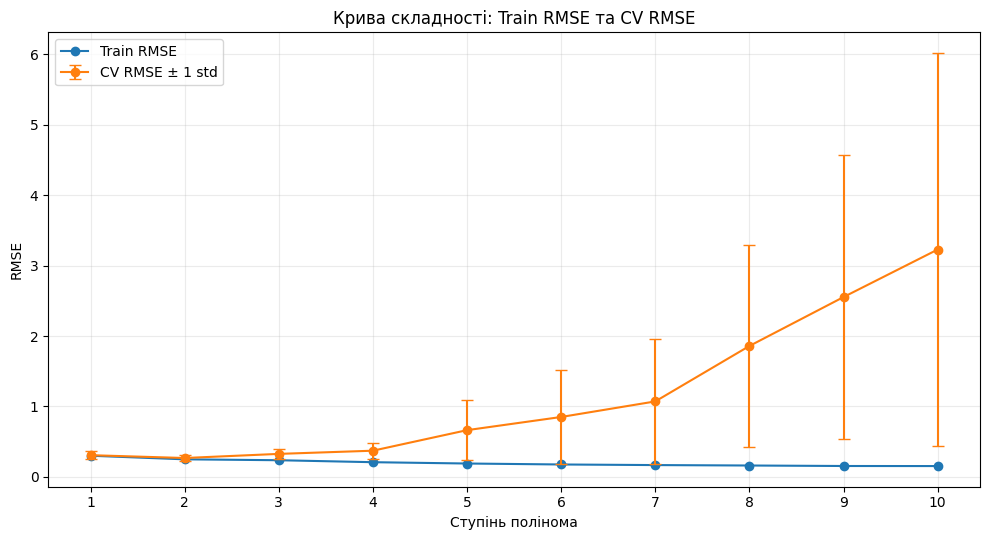

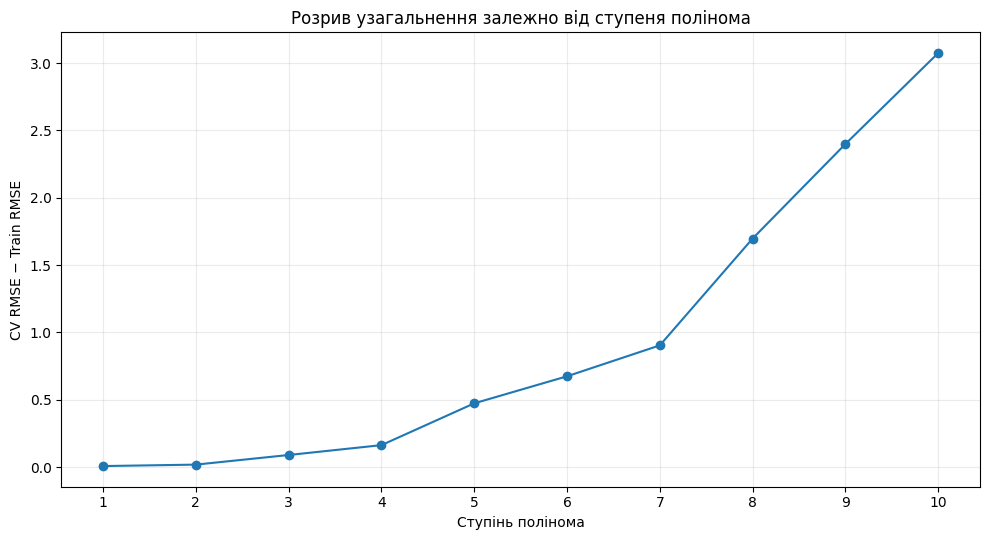

,degree,n_features,train_rmse_mean,cv_rmse_mean,cv_rmse_std,cv_rmse_se,generalization_gap,mean_fit_time_sec,total_cv_time_sec
0,1,3,0.30072,0.30856,0.05876,0.02628,0.00785,0.37558,1.90049
1,2,9,0.24965,0.26822,0.04557,0.02038,0.01857,0.09236,0.48606
2,3,19,0.23677,0.32681,0.06674,0.02985,0.09004,0.01279,0.09347
3,4,34,0.20887,0.37213,0.11630,0.05201,0.16326,0.01621,0.10921
4,5,55,0.19013,0.66383,0.42294,0.18914,0.47370,0.01258,0.08805
5,6,83,0.17638,0.85101,0.67440,0.30160,0.67463,0.01590,0.10675
6,7,119,0.16789,1.07212,0.89344,0.39956,0.90423,0.01543,0.11020
7,8,164,0.16181,1.85935,1.43002,0.63952,1.69754,0.01438,0.09874
8,9,219,0.15480,2.55443,2.02319,0.90480,2.39964,0.01498,0.10084
9,10,285,0.15384,3.22914,2.79190,1.24858,3.07531,0.01527,0.10304


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(poly_results["degree"], poly_results["train_rmse_mean"], marker="o", label="Train RMSE")
ax.errorbar(
    poly_results["degree"], poly_results["cv_rmse_mean"],
    yerr=poly_results["cv_rmse_std"],
    fmt="o-", capsize=4, label="CV RMSE ± 1 std"
)
ax.set_title("Крива складності: Train RMSE та CV RMSE")
ax.set_xlabel("Ступінь полінома")
ax.set_ylabel("RMSE")
ax.set_xticks(DEGREES)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "01_complexity_train_vs_cv_rmse.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(poly_results["degree"], poly_results["gap"], marker="o")
ax.set_title("Розрив узагальнення залежно від ступеня полінома")
ax.set_xlabel("Ступінь полінома")
ax.set_ylabel("CV RMSE − Train RMSE")
ax.set_xticks(DEGREES)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_generalization_gap.png", dpi=160)
plt.show()

# окрема компактна таблиця для пункту 4 методички
poly_diagnostic_table = poly_results[[
    "degree", "n_polynomial_features", "train_rmse_mean",
    "cv_rmse_mean", "cv_rmse_std", "cv_rmse_se", "gap",
    "mean_fit_time_sec", "total_cv_time_sec"
]].copy()
poly_diagnostic_table.columns = [
    "degree", "n_features", "train_rmse_mean", "cv_rmse_mean",
    "cv_rmse_std", "cv_rmse_se", "generalization_gap",
    "mean_fit_time_sec", "total_cv_time_sec"
]
display(poly_diagnostic_table.round(5))
poly_diagnostic_table.to_csv(FIG_DIR / "poly_diagnostic_table.csv", index=False)


### 4.2. Діагностика недонавчання та перенавчання

- **Недонавчання:** область малих ступенів, де train RMSE і CV RMSE обидві залишаються відносно високими, а збільшення ступеня дає помітне покращення CV RMSE.
- **Найкраще узагальнення:** ступінь із мінімальним mean CV RMSE; додатково враховуємо `±1 std` та стандартну похибку середнього `SE = std / √5`.
- **Перенавчання:** область, де train RMSE продовжує зменшуватися, але CV RMSE та generalization gap зростають.
- **Стійкість висновку:** оцінюємо не лише середнє CV RMSE, а й стандартне відхилення/SE між однаковими 5 folds.

У цьому dataset повний контрольований stress test не потрібен: максимум дорівнює лише 285 поліноміальним ознакам для 3 вхідних числових ознак, тому шкала 1–10 є достатньо складною для перевірки перенавчання без необґрунтованого ризику пам'яті або часу виконання.


## 5. Побудова кривих навчання

Для порівняння взято degree=1 як модель низької складності та degree=10 як модель з найвираженішим перенавчанням. Для обох моделей використовується однакова 5-fold CV. Через різницю похибок на кілька порядків Y-вісь на графіку має логарифмічну шкалу.


In [5]:
from sklearn.model_selection import learning_curve

def make_poly_linear(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

learning_models = {
    "Degree 1 — низька складність": make_poly_linear(1),
    "Degree 10 — сильне перенавчання": make_poly_linear(10),
}

learning_rows = []
for name, model in learning_models.items():
    train_sizes, train_scores, cv_scores = learning_curve(
        model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.25, 1.0, 6), n_jobs=-1
    )
    for n, tr, va in zip(train_sizes, train_scores, cv_scores):
        learning_rows.append({
            "model": name, "train_size": int(n),
            "train_rmse_mean": -tr.mean(), "train_rmse_std": tr.std(ddof=1),
            "cv_rmse_mean": -va.mean(), "cv_rmse_std": va.std(ddof=1),
        })
learning_results = pd.DataFrame(learning_rows)
display(learning_results.round(4))


,model,train_size,train_rmse_mean,train_rmse_std,cv_rmse_mean,cv_rmse_std
0,Degree 1 — низька складність,24,0.2736,0.0195,0.3351,0.0658
1,Degree 1 — низька складність,38,0.3055,0.0253,0.3290,0.0785
2,Degree 1 — низька складність,52,0.3100,0.0214,0.3163,0.0658
3,Degree 1 — низька складність,67,0.3033,0.0143,0.3124,0.0664
4,Degree 1 — низька складність,81,0.3039,0.0183,0.3102,0.0649
5,Degree 1 — низька складність,96,0.3007,0.0147,0.3086,0.0588
6,Degree 10 — сильне перенавчання,24,0.0010,0.0022,22.0844,21.8561
7,Degree 10 — сильне перенавчання,38,0.0419,0.0177,26.4734,17.2220
8,Degree 10 — сильне перенавчання,52,0.0668,0.0099,15.1058,19.0978
9,Degree 10 — сильне перенавчання,67,0.0884,0.0095,12.4207,7.2626


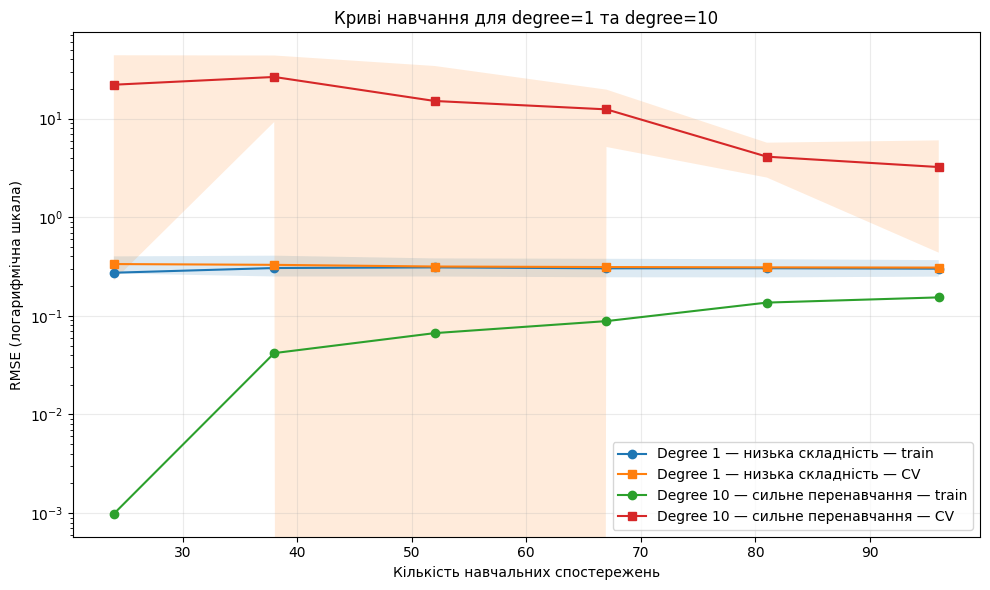

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, grp in learning_results.groupby("model"):
    ax.plot(grp["train_size"], grp["train_rmse_mean"], marker="o", label=f"{name} — train")
    ax.plot(grp["train_size"], grp["cv_rmse_mean"], marker="s", label=f"{name} — CV")
    ax.fill_between(grp["train_size"], grp["cv_rmse_mean"]-grp["cv_rmse_std"], grp["cv_rmse_mean"]+grp["cv_rmse_std"], alpha=0.15)
ax.set_yscale("log")
ax.set_xlabel("Кількість навчальних спостережень")
ax.set_ylabel("RMSE (логарифмічна шкала)")
ax.set_title("Криві навчання для degree=1 та degree=10")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_learning_curves.png", dpi=160, bbox_inches="tight")
plt.show()


### Інтерпретація кривих навчання

**Degree=1:** train і CV RMSE зближені, тому основна проблема — обмежена складність. Збільшення даних може дещо стабілізувати оцінку, але для суттєвого покращення доцільніше перейти до degree=2–3.

**Degree=10:** train RMSE дуже мала, а CV RMSE значно більша; криві мають великий розрив і не зближуються достатньо. Додаткові дані можуть зменшити gap, але першою зміною має бути зменшення складності або регуляризація.


## 6. Застосування регуляризації

Вибрано один складний простір ознак: **PolynomialFeatures(degree=10)**. Для LinearRegression, Ridge, Lasso та ElasticNet використано однакову структуру `PolynomialFeatures → StandardScaler → модель`, однаковий 5-fold `KFold` і основну метрику RMSE.

Критерій покращення: менший CV RMSE; за близьких значень — менший generalization gap та/або менший `CV RMSE std`. Для Lasso та ElasticNet додатково перевіряється кількість ненульових коефіцієнтів. Для ElasticNet використано великий `max_iter`, а `ConvergenceWarning` не приховуються.


Фіксовані значення: Ridge `alpha=0.1`, Lasso `alpha=0.001`, Elastic Net `alpha=0.001`, `l1_ratio=0.7`. Їх можна отримати/уточнювати на окремому етапі grid search, але такий пошук не змішується з цією контрольованою порівняльною перевіркою.


In [7]:
COMPLEX_DEGREE = 10

# Спільний простір ознак і однакова CV-схема для всіх чотирьох моделей.
# Гіперпараметри регуляризованих моделей фіксуємо з попереднього дослідницького етапу:
# Ridge alpha=0.1, Lasso alpha=0.001, ElasticNet alpha=0.001, l1_ratio=0.7.
# Це не підміна CV: у цьому пункті перевіряється саме ефект регуляризації на однаковому просторі.
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=0.1),
    "Lasso": Lasso(alpha=0.001, max_iter=100000, tol=1e-5),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.7, max_iter=300000, tol=1e-5, random_state=42),
}

regularization_results = []
warning_log = []
for name, estimator in models.items():
    model_pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=COMPLEX_DEGREE, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        scores = cross_validate(
            model_pipe, X_train, y_train, cv=cv,
            scoring="neg_root_mean_squared_error",
            return_train_score=True, n_jobs=1
        )
    warning_log.extend((name, type(w.message).__name__, str(w.message)) for w in caught)
    train_rmse = -scores["train_score"]
    cv_rmse = -scores["test_score"]
    regularization_results.append({
        "model": name,
        "train_rmse_mean": train_rmse.mean(),
        "cv_rmse_mean": cv_rmse.mean(),
        "cv_rmse_std": cv_rmse.std(ddof=1),
        "cv_rmse_se": cv_rmse.std(ddof=1) / np.sqrt(N_SPLITS),
        "generalization_gap": cv_rmse.mean() - train_rmse.mean(),
        "mean_fit_time_sec": scores["fit_time"].mean(),
    })

regularization_results = pd.DataFrame(regularization_results).sort_values("cv_rmse_mean")
display(regularization_results.round(5))

print("Попередження, зафіксовані під час CV:")
if warning_log:
    for item in sorted(set(warning_log)):
        print(item)
else:
    print("Попереджень не зафіксовано.")

regularization_results.to_csv(FIG_DIR / "regularization_results.csv", index=False)


,model,train_rmse_mean,cv_rmse_mean,cv_rmse_std,cv_rmse_se,generalization_gap,mean_fit_time_sec
2,Lasso,0.24720,0.27107,0.05690,0.02545,0.02387,0.64765
3,ElasticNet,0.24570,0.27327,0.05469,0.02446,0.02757,0.72322
1,Ridge,0.23552,0.30040,0.03571,0.01597,0.06488,0.00742
0,LinearRegression,0.15384,3.22914,2.79190,1.24858,3.07531,0.06870


Попередження, зафіксовані під час CV:
Попереджень не зафіксовано.


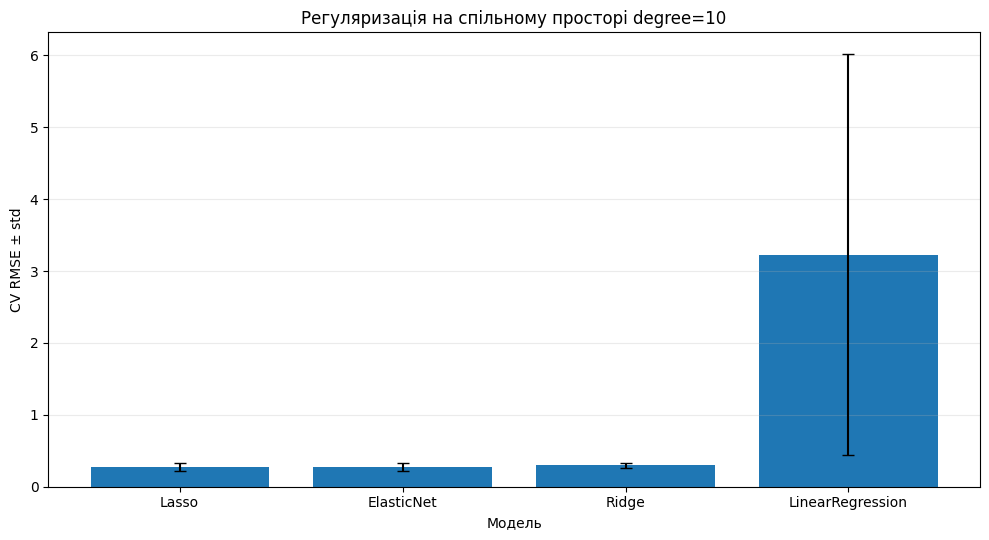

In [8]:
fig, ax = plt.subplots(figsize=(10,5.5))
r=regularization_results
ax.bar(r["model"],r["cv_rmse_mean"],yerr=r["cv_rmse_std"],capsize=4)
ax.set_xlabel("Модель")
ax.set_ylabel("CV RMSE ± std")
ax.set_title("Регуляризація на спільному просторі degree=10")
ax.grid(True,axis="y",alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_regularization_comparison.png",dpi=160,bbox_inches="tight")
plt.show()


In [9]:
# Додаткова характеристика простоти для Lasso та Elastic Net
nonzero_rows = []
for name in ["Lasso", "ElasticNet"]:
    estimator = models[name]
    p = Pipeline([
        ("poly", PolynomialFeatures(degree=COMPLEX_DEGREE, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    fold_counts = []
    for train_idx, _ in cv.split(X_train, y_train):
        p.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        fold_counts.append(np.count_nonzero(np.abs(p.named_steps["model"].coef_) > 1e-6))
    nonzero_rows.append({"model": name, "mean_nonzero_coefficients": np.mean(fold_counts), "total_polynomial_features": len(p.named_steps["poly"].get_feature_names_out())})
nonzero_df = pd.DataFrame(nonzero_rows)
display(nonzero_df.round(3))
nonzero_df.to_csv(FIG_DIR / "regularization_nonzero_coefficients.csv", index=False)


,model,mean_nonzero_coefficients,total_polynomial_features
0,Lasso,11.0,285
1,ElasticNet,21.6,285


### Висновок за пунктом 6

Регуляризація вважається корисною не просто через меншу train RMSE. Основним критерієм є менший CV RMSE; за близької якості додатковими аргументами є менший generalization gap, менший CV RMSE std та менша кількість ненульових коефіцієнтів. Попередження про збіжність не приховуються: якщо вони з'являються, notebook виводить їх тип і текст, після чого причину можна пов'язати з параметрами оптимізації (`max_iter`, `tol`) та силою регуляризації.


## 7. Вибір гіперпараметрів регуляризації

Підбір `alpha` виконується **тільки на навчальній вибірці** за однаковою 5-fold схемою. Test set не використовується для вибору або розширення діапазону. Використано логарифмічну сітку `alpha = 10^k` для `k = -6, -5, ..., 4`, яка містить область майже відсутньої, помірної та надмірної регуляризації. Для Elastic Net додатково перевірено `l1_ratio = 0.2, 0.5, 0.8`.

In [10]:
ALPHAS = np.logspace(-6, 4, 11)
L1_RATIOS = [0.2, 0.5, 0.8]

# Всі кандидати використовують однакові folds та однаковий простір ознак degree=10.
cv_fixed = KFold(n_splits=5, shuffle=True, random_state=42)

def regularized_pipeline(model):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=COMPLEX_DEGREE, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

alpha_rows = []
for model_name, model_grid in {
    "Ridge": [Ridge(alpha=a) for a in ALPHAS],
    "Lasso": [Lasso(alpha=a, max_iter=100000) for a in ALPHAS],
}.items():
    for alpha, model in zip(ALPHAS, model_grid):
        pipe = regularized_pipeline(model)
        res = cross_validate(pipe, X_train, y_train, cv=cv_fixed, scoring="neg_root_mean_squared_error",
                             return_train_score=True, n_jobs=-1)
        tr = -res["train_score"]
        cvv = -res["test_score"]
        alpha_rows.append({
            "model": model_name, "alpha": alpha,
            "train_rmse_mean": tr.mean(), "cv_rmse_mean": cvv.mean(),
            "cv_rmse_std": cvv.std(ddof=1), "generalization_gap": cvv.mean()-tr.mean()
        })

for ratio in L1_RATIOS:
    for alpha in ALPHAS:
        pipe = regularized_pipeline(ElasticNet(alpha=alpha, l1_ratio=ratio, max_iter=100000))
        res = cross_validate(pipe, X_train, y_train, cv=cv_fixed, scoring="neg_root_mean_squared_error",
                             return_train_score=True, n_jobs=-1)
        tr = -res["train_score"]
        cvv = -res["test_score"]
        alpha_rows.append({
            "model": "ElasticNet", "l1_ratio": ratio, "alpha": alpha,
            "train_rmse_mean": tr.mean(), "cv_rmse_mean": cvv.mean(),
            "cv_rmse_std": cvv.std(ddof=1), "generalization_gap": cvv.mean()-tr.mean()
        })

alpha_results = pd.DataFrame(alpha_rows)
best_alpha_rows = []
for model_name in ["Ridge", "Lasso"]:
    sub = alpha_results[alpha_results.model.eq(model_name)].copy()
    best_alpha_rows.append(sub.loc[sub.cv_rmse_mean.idxmin()].to_dict())
sub = alpha_results[alpha_results.model.eq("ElasticNet")].copy()
best_en = sub.loc[sub.cv_rmse_mean.idxmin()].to_dict()
best_alpha_rows.append(best_en)
best_alpha = pd.DataFrame(best_alpha_rows)
print(best_alpha[["model", "alpha", "l1_ratio", "cv_rmse_mean", "cv_rmse_std", "generalization_gap"]].to_string(index=False))

     model  alpha  l1_ratio  cv_rmse_mean  cv_rmse_std  generalization_gap
     Ridge  1.000       NaN      0.277018     0.056700            0.030027
     Lasso  0.001       NaN      0.271007     0.056886            0.023824
ElasticNet  0.010       0.2      0.269002     0.063065            0.012362


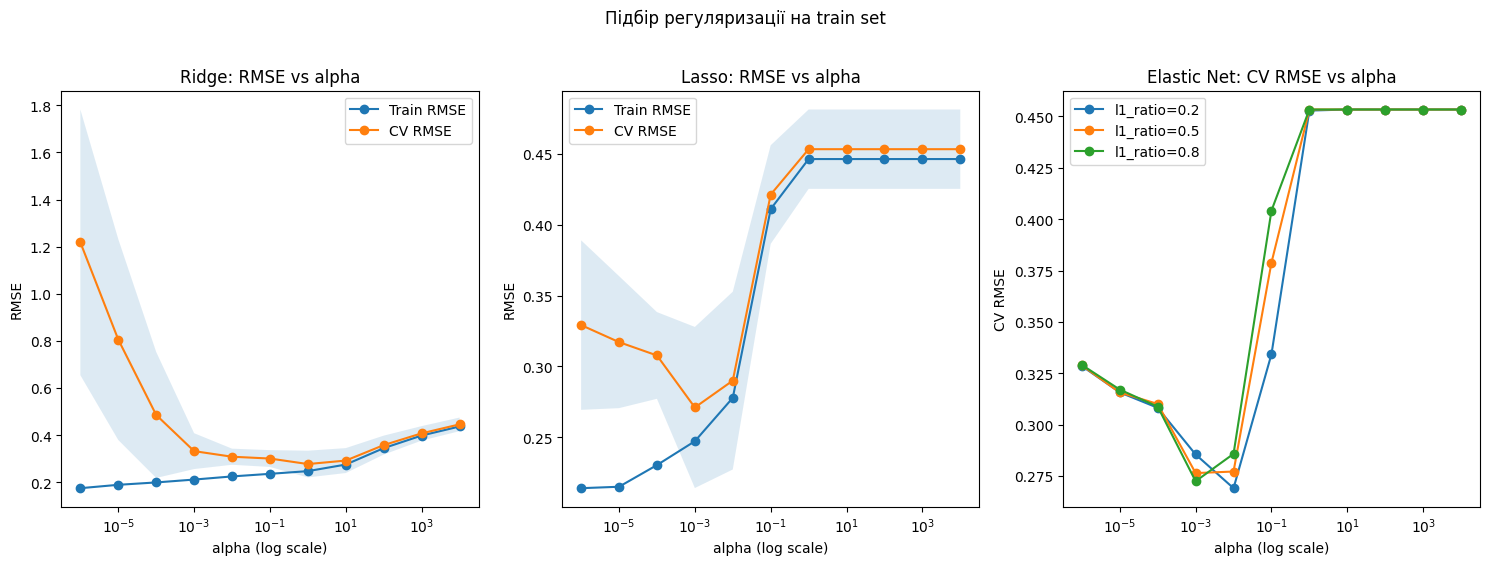

In [11]:
# Візуалізація train/CV RMSE як функції alpha.
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
plot_specs = [("Ridge", None, axes[0]), ("Lasso", None, axes[1])]
for name, ratio, ax in plot_specs:
    sub = alpha_results[alpha_results.model.eq(name)].sort_values("alpha")
    ax.set_xscale("log")
    ax.plot(sub.alpha, sub.train_rmse_mean, marker="o", label="Train RMSE")
    ax.plot(sub.alpha, sub.cv_rmse_mean, marker="o", label="CV RMSE")
    ax.fill_between(sub.alpha, sub.cv_rmse_mean-sub.cv_rmse_std, sub.cv_rmse_mean+sub.cv_rmse_std, alpha=0.15)
    ax.set_title(f"{name}: RMSE vs alpha")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("RMSE")
    ax.legend()

ax = axes[2]
for ratio in L1_RATIOS:
    sub = alpha_results[(alpha_results.model.eq("ElasticNet")) & (alpha_results.l1_ratio.eq(ratio))].sort_values("alpha")
    ax.plot(sub.alpha, sub.cv_rmse_mean, marker="o", label=f"l1_ratio={ratio}")
ax.set_xscale("log")
ax.set_title("Elastic Net: CV RMSE vs alpha")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("CV RMSE")
ax.legend()
fig.suptitle("Підбір регуляризації на train set", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_alpha_search.png", dpi=160, bbox_inches="tight")
plt.show()

### 7.1. Інтерпретація підбору alpha

Область слабкої регуляризації відповідає малим `alpha`, де train RMSE низька, але розрив узагальнення може бути великим. Область надмірної регуляризації відповідає великим `alpha`, де одночасно зростає train RMSE і, після проходження мінімуму, CV RMSE. Оптимальним вважається значення, що мінімізує **CV RMSE на train set**. Якщо мінімум опинився на межі сітки, діапазон слід розширити як окремий етап і не змінювати його за test-результатом.

In [12]:
# Збереження таблиці alpha search.
alpha_results.to_csv(FIG_DIR / "alpha_search_results.csv", index=False)
best_alpha.to_csv(FIG_DIR / "best_regularization_params.csv", index=False)
print("Alpha search results saved.")

Alpha search results saved.


## 8. Аналіз ефекту регуляризації

Для вибраних за CV конфігурацій обчислюємо RMSE, generalization gap, норму коефіцієнтів L2 (`||w||_2`) та кількість ненульових коефіцієнтів для Lasso/Elastic Net. Це дає змогу перевірити, чи покращення CV RMSE супроводжується меншим розривом і контрольованою складністю.

In [13]:
# Оцінка вибраних за CV конфігурацій на train та один фінальний test score.
selected_models = {}
for row in best_alpha.to_dict("records"):
    name = row["model"]
    if name == "Ridge":
        est = Ridge(alpha=float(row["alpha"]))
    elif name == "Lasso":
        est = Lasso(alpha=float(row["alpha"]), max_iter=100000)
    else:
        est = ElasticNet(alpha=float(row["alpha"]), l1_ratio=float(row["l1_ratio"]), max_iter=100000)
    selected_models[name] = regularized_pipeline(est)

selected_rows=[]
for name, pipe in selected_models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv_fixed, scoring="neg_root_mean_squared_error",
                         return_train_score=True, n_jobs=-1)
    tr=-res["train_score"]; cvv=-res["test_score"]
    pipe.fit(X_train, y_train)
    pred=pipe.predict(X_test)
    coef=pipe.named_steps["model"].coef_
    selected_rows.append({
        "model":name, "alpha":best_alpha.loc[best_alpha.model.eq(name),"alpha"].iloc[0],
        "l1_ratio":best_alpha.loc[best_alpha.model.eq(name),"l1_ratio"].iloc[0] if "l1_ratio" in best_alpha.columns else np.nan,
        "train_rmse":tr.mean(), "cv_rmse":cvv.mean(), "cv_std":cvv.std(ddof=1),
        "gap":cvv.mean()-tr.mean(), "l2_coef_norm":float(np.linalg.norm(coef)),
        "nonzero":int(np.sum(np.abs(coef)>1e-10)), "test_rmse":mean_squared_error(y_test,pred)**0.5,
        "test_r2":r2_score(y_test,pred)
    })
selected_summary=pd.DataFrame(selected_rows)
print(selected_summary.to_string(index=False))
selected_summary.to_csv(FIG_DIR / "selected_regularization_summary.csv", index=False)

     model  alpha  l1_ratio  train_rmse  cv_rmse   cv_std      gap  l2_coef_norm  nonzero  test_rmse   test_r2
     Ridge  1.000       NaN    0.246991 0.277018 0.056700 0.030027      0.810717      285   0.390355 -0.065075
     Lasso  0.001       NaN    0.247183 0.271007 0.056886 0.023824      1.248812       14   0.361570  0.086211
ElasticNet  0.010       0.2    0.256641 0.269002 0.063065 0.012362      0.743171       39   0.351603  0.135896


C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.812717e+00, tolerance: 2.400e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.896042e+00, tolerance: 2.400e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\

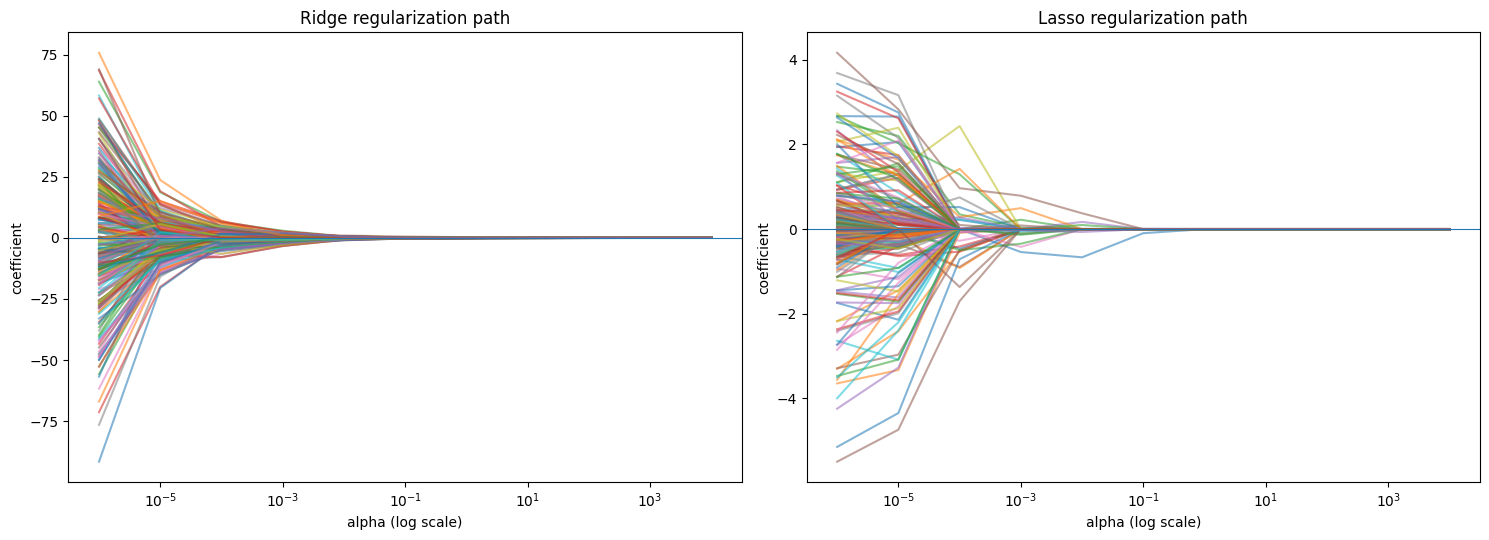

In [14]:
# Регуляризаційні шляхи коефіцієнтів для Ridge і Lasso.
FEATURE_NAMES = PolynomialFeatures(degree=COMPLEX_DEGREE, include_bias=False).fit(X_train).get_feature_names_out(X.columns)
paths=[]
for name, Est in [("Ridge", lambda a: Ridge(alpha=a)), ("Lasso", lambda a: Lasso(alpha=a, max_iter=100000))]:
    for alpha in ALPHAS:
        pipe=regularized_pipeline(Est(alpha))
        pipe.fit(X_train,y_train)
        co=pipe.named_steps["model"].coef_
        for feat,val in zip(FEATURE_NAMES,co):
            paths.append({"model":name,"alpha":alpha,"feature":feat,"coef":val})
coef_paths=pd.DataFrame(paths)
fig, axes=plt.subplots(1,2,figsize=(15,5.5))
for ax,name in zip(axes,["Ridge","Lasso"]):
    sub=coef_paths[coef_paths.model.eq(name)]
    pivot=sub.pivot(index="alpha",columns="feature",values="coef").sort_index()
    for feat in pivot.columns:
        ax.plot(pivot.index,pivot[feat],alpha=0.55)
    ax.set_xscale("log")
    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"{name} regularization path")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("coefficient")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_regularization_paths.png", dpi=160, bbox_inches="tight")
plt.show()
coef_paths.to_csv(FIG_DIR / "regularization_paths.csv", index=False)

### 8.1. Висновки щодо коефіцієнтів і узагальнення

**Ridge** стискає коефіцієнти до нуля, але звичайно не робить їх точно нульовими: L2-штраф карає величину коефіцієнтів, але не створює розрідженість як L1. **Lasso** починає формувати розріджений розв'язок у міру збільшення `alpha`; це видно з кількості ненульових коефіцієнтів і регуляризаційного шляху. Для Elastic Net розрідженість контролюється одночасно `alpha` та `l1_ratio`.

Ознакою втрати істотної інформації через надмірне стиснення є ситуація, коли після мінімуму CV RMSE подальше збільшення `alpha` підвищує і train RMSE, і CV RMSE. Отже, оптимум визначається не максимальною простотою, а компромісом між похибкою та узагальненням. Якщо CV RMSE зменшується разом із generalization gap, це підтримує висновок, що регуляризація покращує узагальнення; якщо gap зменшується, але CV RMSE зростає, регуляризація вже надмірна.